# Duffing Neural ODE — Step 4: additive force decomposition

First-principles structure without knowing the analytical law: a mechanical system's
acceleration is a **sum of forces**, each depending on its own variable — a restoring
force $f(x)$, a damping force $d(\dot{x})$, and a periodic drive $g(\cos\omega t, \sin\omega t)$.
We encode exactly that and nothing more: three small tanh MLPs, no sign constraints,
no polynomial skeleton, no sinusoidal restriction on the drive.

Three models, one ingredient apart, so every gain is attributable:

| model | first row $\dot{x}_1$ | acceleration $\dot{x}_2$ | params |
|---|---|---|---|
| **baseline** (Step 2/3, cached) | learned | one MLP$(x, \dot{x}, \cos\omega t, \sin\omega t)$, 2 outputs | ~4.6k |
| **scalar** | hardwired $= x_2$ | one MLP$(x, \dot{x}, \cos\omega t, \sin\omega t)$, 1 output | ~4.5k |
| **additive** | hardwired $= x_2$ | $f_\theta(x) + d_\theta(\dot{x}) + g_\theta(\cos\omega t, \sin\omega t)$ | ~3.5k |

- baseline → scalar isolates **hardwired kinematics** (rung 1: $\dot{x}_1 = x_2$ exact by
  construction instead of learned).
- scalar → additive isolates **additivity** (no cross-terms representable; each force is a
  1-D function trained wherever its own variable was visited).

Identical data (63-IC grid), identical init seed, identical minibatch stream and Adam
schedule as Steps 2–3. Predictions to falsify: additivity cleans up the interior and the
near-box wrong-well flips (nothing to hallucinate off-axis), but far-field ray error still
grows because tanh subnets saturate while the true $-x^3$ keeps growing — that is the
next rung's job, not this one's.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

DELTA, GAMMA, OMEGA = 0.5, 0.5, 1.7

def true_rhs(s, t):
    x, v = s
    return jnp.array([v, -DELTA * v + x - x**3 + GAMMA * jnp.cos(OMEGA * t)])

def rk4_step(f, s, t, dt):
    k1 = f(s, t)
    k2 = f(s + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(s + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(s + dt * k3, t + dt)
    return s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def simulate(f, s0, t0, n_save, dt_save, substeps):
    dt = dt_save / substeps
    def sub(c, _):
        s, t = c
        return (rk4_step(f, s, t, dt), t + dt), None
    def save_step(carry, _):
        carry, _ = jax.lax.scan(sub, carry, None, length=substeps)
        return carry, carry[0]
    _, traj = jax.lax.scan(save_step, (s0, t0), None, length=n_save)
    return jnp.concatenate([s0[None], traj])

T_END, DT_INT, DT_SAVE = 20.0, 0.005, 0.01
SUBS = int(round(DT_SAVE / DT_INT))
N_SAVE = int(round(T_END / DT_SAVE))
times = np.arange(N_SAVE + 1) * DT_SAVE

X0_LIM, V0_LIM = 0.75, 0.4
ic_grid = np.stack(np.meshgrid(np.linspace(-X0_LIM, X0_LIM, 9),
                               np.linspace(-V0_LIM, V0_LIM, 7),
                               indexing='ij'), axis=-1).reshape(-1, 2)

sim_batch = jax.vmap(lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
trajs = np.asarray(sim_batch(jnp.asarray(ic_grid)))
print('training trajectories:', trajs.shape)

training trajectories: (63, 2001, 2)


## The three models

Shared MLP machinery; each model is defined by an init function and an `rhs`. The scalar
and additive models return $(x_2, a_\theta)$ — the velocity row is copied from the state,
exact everywhere by construction, and carries no parameters. The additive model's
parameters are one flat list of $(W, b)$ pairs (3 layers each for $f$, $d$, $g$) so the
shared training/cache harness handles all three models identically.

In [2]:
def init_mlp(key, layers):
    params = []
    for n_in, n_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        W = jax.random.normal(k, (n_in, n_out)) * jnp.sqrt(1.0 / n_in)
        params.append((W, jnp.zeros(n_out)))
    return params

def mlp(params, u):
    h = u
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    return h @ W + b

def make_input(s, t):
    return jnp.array([s[0], s[1], jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)])

LAYERS_BASE = [4, 64, 64, 2]
def init_base(key):
    return init_mlp(key, LAYERS_BASE)
def rhs_base(params, s, t):
    return mlp(params, make_input(s, t))

LAYERS_SCALAR = [4, 64, 64, 1]
def init_scalar(key):
    return init_mlp(key, LAYERS_SCALAR)
def rhs_scalar(params, s, t):
    a = mlp(params, make_input(s, t))[0]
    return jnp.array([s[1], a])

F_LAYERS = [1, 32, 32, 1]
D_LAYERS = [1, 32, 32, 1]
G_LAYERS = [2, 32, 32, 1]
N_F, N_D = len(F_LAYERS) - 1, len(D_LAYERS) - 1

def init_additive(key):
    kf, kd, kg = jax.random.split(key, 3)
    return (init_mlp(kf, F_LAYERS) + init_mlp(kd, D_LAYERS)
            + init_mlp(kg, G_LAYERS))

def additive_terms(params, s, t):
    pf = params[:N_F]
    pd = params[N_F:N_F + N_D]
    pg = params[N_F + N_D:]
    f = mlp(pf, jnp.array([s[0]]))[0]
    d = mlp(pd, jnp.array([s[1]]))[0]
    g = mlp(pg, jnp.array([jnp.cos(OMEGA * t), jnp.sin(OMEGA * t)]))[0]
    return f, d, g

def rhs_additive(params, s, t):
    f, d, g = additive_terms(params, s, t)
    return jnp.array([s[1], f + d + g])

for name, init in [('baseline', init_base), ('scalar', init_scalar),
                   ('additive', init_additive)]:
    n = sum(W.size + b.size for W, b in init(jax.random.PRNGKey(0)))
    print(f'{name:9s} parameters: {n}')

baseline  parameters: 4610
scalar    parameters: 4545


additive  parameters: 3491


## Training harness

Same harness as Step 3: `PRNGKey(0)` init, `PRNGKey(1)` minibatch stream, lr 1e-3 → 1e-4
at step 8000, 12000 steps, full-dataset loss every 250 steps, parameters cached to
`params_<tag>.npz` (delete the file to retrain). The baseline's tag is `baseline`, so it
**loads the Step-3 cache directly** — bit-identical weights, zero training time. The loss
is one-step state-prediction MSE for every model; for the hardwired models the velocity
row's contribution is integrator truncation only, so their losses are not directly
comparable to the baseline's — rollout metrics below are the fair comparison.

In [3]:
import os

s_now = jnp.asarray(trajs[:, :-1, :].reshape(-1, 2))
s_next = jnp.asarray(trajs[:, 1:, :].reshape(-1, 2))
t_now = jnp.asarray(np.tile(times[:-1], len(ic_grid)))
N_PAIRS = s_now.shape[0]
print('training pairs:', N_PAIRS)

def adam_update(params, grads, m, v, step, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g: b1 * m_ + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: b2 * v_ + (1 - b2) * g * g, v, grads)
    mhat = jax.tree.map(lambda m_: m_ / (1 - b1 ** step), m)
    vhat = jax.tree.map(lambda v_: v_ / (1 - b2 ** step), v)
    new = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                       params, mhat, vhat)
    return new, m, v

BATCH = 16384
N_STEPS = 12000
EVAL_EVERY = 250

def train(rhs, init_fn, tag):
    def one_step(params, s, t):
        return rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)

    def loss_on(params, sb, snb, tb):
        pred = jax.vmap(lambda s, t: one_step(params, s, t))(sb, tb)
        return jnp.mean((pred - snb) ** 2)

    full_loss = jax.jit(lambda p: loss_on(p, s_now, s_next, t_now))

    cache = f'params_{tag}.npz'
    if os.path.exists(cache):
        z = np.load(cache)
        n_layers = sum(1 for k in z.files if k.startswith('W'))
        params = [(jnp.asarray(z[f'W{i}']), jnp.asarray(z[f'b{i}']))
                  for i in range(n_layers)]
        print(f'[{tag}] loaded cached params from {cache}   '
              f'full loss {float(full_loss(params)):.3e}   '
              f'(delete the file to retrain)')
        return (params, z['hist_steps'], z['hist_loss'], full_loss,
                float(z['wall']))

    @jax.jit
    def train_step(params, m, v, step, lr, key):
        idx = jax.random.randint(key, (BATCH,), 0, N_PAIRS)
        loss, grads = jax.value_and_grad(loss_on)(params, s_now[idx],
                                                  s_next[idx], t_now[idx])
        params, m, v = adam_update(params, grads, m, v, step, lr)
        return params, m, v, loss

    params = init_fn(jax.random.PRNGKey(0))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    base_key = jax.random.PRNGKey(1)

    hist_steps, hist_loss = [], []
    t0 = time.time()
    for i in range(1, N_STEPS + 1):
        lr = 1e-3 if i <= 8000 else 1e-4
        params, m, v, _ = train_step(params, m, v, float(i), lr,
                                     jax.random.fold_in(base_key, i))
        if i == 1 or i % EVAL_EVERY == 0:
            fl = float(full_loss(params))
            hist_steps.append(i)
            hist_loss.append(fl)
            if i == 1 or i % 2000 == 0:
                print(f'[{tag}] step {i:6d}   lr {lr:.0e}   full loss {fl:.3e}')
    wall = time.time() - t0
    print(f'[{tag}] final full loss {hist_loss[-1]:.3e}   wall time {wall:.0f} s')
    np.savez(cache, hist_steps=np.array(hist_steps),
             hist_loss=np.array(hist_loss), wall=wall,
             **{f'W{i}': np.asarray(W) for i, (W, _) in enumerate(params)},
             **{f'b{i}': np.asarray(b) for i, (_, b) in enumerate(params)})
    return params, np.array(hist_steps), np.array(hist_loss), full_loss, wall

params_b, steps_b, loss_b, _, wall_b = train(rhs_base, init_base, 'baseline')
params_s, steps_s, loss_s, _, wall_s = train(rhs_scalar, init_scalar, 'scalaracc')
params_a, steps_a, loss_a, _, wall_a = train(rhs_additive, init_additive, 'additive')

MODELS = [('baseline', rhs_base, params_b, 'k'),
          ('scalar', rhs_scalar, params_s, 'tab:blue'),
          ('additive', rhs_additive, params_a, 'tab:green')]

training pairs: 126000


[baseline] loaded cached params from params_baseline.npz   full loss 1.804e-09   (delete the file to retrain)


[scalaracc] step      1   lr 1e-03   full loss 3.570e-05


[scalaracc] step   2000   lr 1e-03   full loss 3.581e-08


[scalaracc] step   4000   lr 1e-03   full loss 5.996e-09


...

[additive] step   4000   lr 1e-03   full loss 7.867e-09


[additive] step   6000   lr 1e-03   full loss 3.020e-09


[additive] step   8000   lr 1e-03   full loss 1.862e-09


[additive] step  10000   lr 1e-04   full loss 1.741e-09


[additive] step  12000   lr 1e-04   full loss 1.623e-09
[additive] final full loss 1.623e-09   wall time 154 s


## 1 — Learning curves

Same caveat as above: the two hardwired models get the velocity row for free, so their
one-step losses start lower and are not on the same scale as the baseline's. Compare
scalar vs additive directly; compare against the baseline only in the rollout metrics.

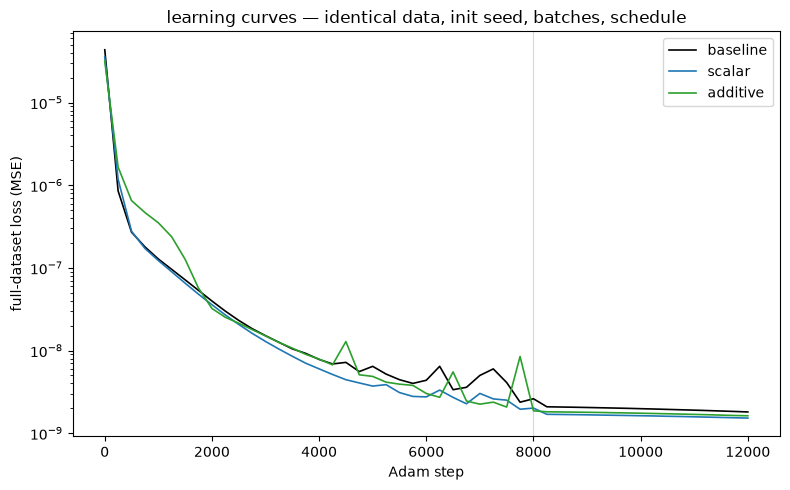

final loss   baseline 1.804e-09   scalar 1.521e-09   additive 1.623e-09
wall time    baseline 136 s   scalar 133 s   additive 154 s


In [4]:
fig, a = plt.subplots(figsize=(8, 5))
for (tag, _, _, color), st, lo in [(MODELS[0], steps_b, loss_b),
                                   (MODELS[1], steps_s, loss_s),
                                   (MODELS[2], steps_a, loss_a)]:
    a.semilogy(st, lo, color=color, lw=1.2, label=tag)
a.axvline(8000, color='0.85', lw=0.8, zorder=0)
a.set_xlabel('Adam step')
a.set_ylabel('full-dataset loss (MSE)')
a.set_title('learning curves — identical data, init seed, batches, schedule')
a.legend()
plt.tight_layout(); plt.show()

print(f'final loss   baseline {loss_b[-1]:.3e}   scalar {loss_s[-1]:.3e}'
      f'   additive {loss_a[-1]:.3e}')
print(f'wall time    baseline {wall_b:.0f} s   scalar {wall_s:.0f} s'
      f'   additive {wall_a:.0f} s')

## 2 — Accuracy: one-step errors and held-out ICs

One-step state-prediction error over all 126k pairs, then free 20 s rollouts from the
five held-out interior ICs used in Steps 2–3.

In [5]:
def one_step_errors(rhs, params):
    f = lambda s, t: rk4_step(lambda s_, t_: rhs(params, s_, t_), s, t, DT_SAVE)
    pred = jax.vmap(f)(s_now, t_now)
    return np.asarray(jnp.linalg.norm(pred - s_next, axis=1))

for tag, rhs, p, _ in MODELS:
    e = one_step_errors(rhs, p)
    print(f'{tag:9s} one-step error   median {np.median(e):.2e}'
          f'   mean {e.mean():.2e}   max {e.max():.2e}')

INTERP_ICS = [(0.33, 0.17), (-0.61, -0.29), (0.05, -0.37), (0.7, 0.35), (-0.5, 0.0)]

def rollout_err(rhs, params, ic):
    s0 = jnp.array(ic)
    tru = np.asarray(simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))
    rol = np.asarray(simulate(lambda s, t: rhs(params, s, t),
                              s0, 0.0, N_SAVE, DT_SAVE, 1))
    err = np.linalg.norm(rol - tru, axis=1)
    same_well = (tru[-1, 0] > 0) == (rol[-1, 0] > 0)
    return err.mean(), same_well

print()
print('held-out IC rollouts (mean error over 20 s):')
print(f'{"IC":>16s} {"baseline":>12s} {"scalar":>12s} {"additive":>12s}'
      '   wells correct?')
for ic in INTERP_ICS:
    row, wells = [], []
    for tag, rhs, p, _ in MODELS:
        e, w = rollout_err(rhs, p, ic)
        row.append(e)
        wells.append(w)
    print(f'{str(ic):>16s} {row[0]:>12.2e} {row[1]:>12.2e} {row[2]:>12.2e}'
          f'   {wells[0]} / {wells[1]} / {wells[2]}')

baseline  one-step error   median 2.45e-05   mean 4.03e-05   max 4.22e-04
scalar    one-step error   median 1.98e-05   mean 3.51e-05   max 4.35e-04


additive  one-step error   median 3.66e-05   mean 4.01e-05   max 7.21e-04

held-out IC rollouts (mean error over 20 s):
              IC     baseline       scalar     additive   wells correct?


    (0.33, 0.17)     3.24e-03     2.79e-03     2.70e-03   True / True / True


  (-0.61, -0.29)     3.54e-03     4.82e-03     3.82e-03   True / True / True


   (0.05, -0.37)     6.81e-03     8.88e-03     2.67e-03   True / True / True


     (0.7, 0.35)     2.51e-03     1.45e-03     2.39e-03   True / True / True


     (-0.5, 0.0)     8.16e-03     5.18e-03     4.39e-03   True / True / True


## 3 — Extrapolation rays, with data coverage

The Step-2/3 ray sweep, all three models, with the training-data coverage strip from the
Step-3 notebook behind the curves (kernel-smoothed density of all 126k training states;
darker = more nearby data, red dashed = IC box). The additivity prediction: fewer
wrong-well flips near the coverage edge, but the deep far field stays broken — the tanh
subnets still saturate while the true $-x^3$ grows.

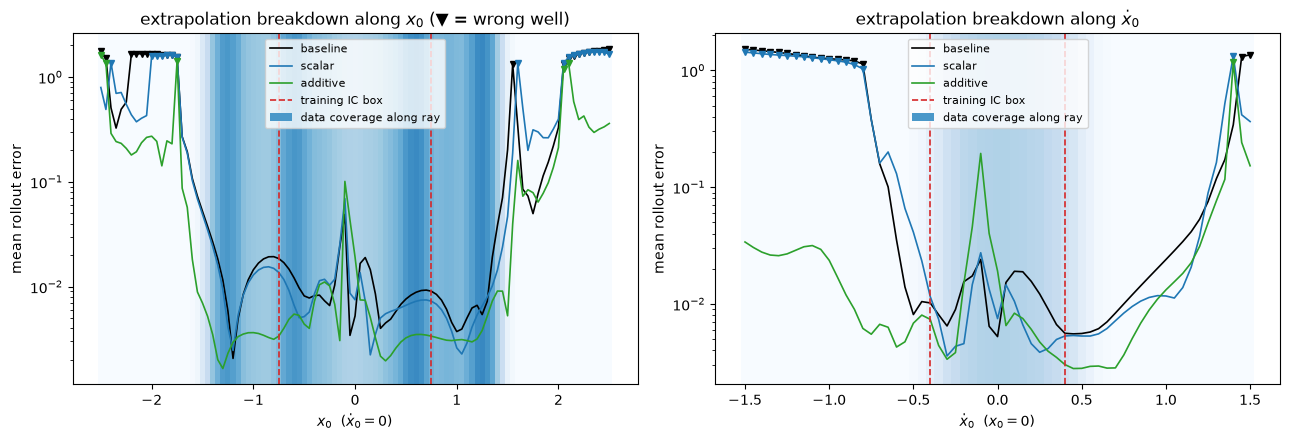

--- ray along x0 ---
  baseline  median err 1.91e-02   wrong-well starts: 23/101
  scalar    median err 1.50e-02   wrong-well starts: 18/101
  additive  median err 7.30e-03   wrong-well starts: 5/101
--- ray along v0 ---
  baseline  median err 2.40e-02   wrong-well starts: 17/61
  scalar    median err 2.07e-02   wrong-well starts: 16/61
  additive  median err 8.98e-03   wrong-well starts: 1/61


In [6]:
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch

pts = np.asarray(s_now)
BIN, SIG = 0.02, 0.08
XB = np.arange(-2.6, 2.6 + 1e-9, BIN)
VB = np.arange(-1.8, 1.8 + 1e-9, BIN)
H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=[XB, VB])
D_log = np.log10(1.0 + gaussian_filter(H, SIG / BIN))
D_norm = D_log / D_log.max()
xc = 0.5 * (XB[:-1] + XB[1:])
vc = 0.5 * (VB[:-1] + VB[1:])

def coverage_at(x, v):
    i = np.clip(np.searchsorted(xc, x), 0, len(xc) - 1)
    j = np.clip(np.searchsorted(vc, v), 0, len(vc) - 1)
    return D_norm[i, j]

def ray_errors(rhs, params, ics):
    ics = jnp.asarray(ics)
    f = lambda s, t: rhs(params, s, t)
    tru = np.asarray(jax.vmap(
        lambda s0: simulate(true_rhs, s0, 0.0, N_SAVE, DT_SAVE, SUBS))(ics))
    rol = np.asarray(jax.vmap(
        lambda s0: simulate(f, s0, 0.0, N_SAVE, DT_SAVE, 1))(ics))
    err = np.linalg.norm(rol - tru, axis=2).mean(axis=1)
    wrong_well = (tru[:, -1, 0] > 0) != (rol[:, -1, 0] > 0)
    return err, wrong_well

x_ray = np.linspace(-2.5, 2.5, 101)
v_ray = np.linspace(-1.5, 1.5, 61)
rays = {'x': np.stack([x_ray, np.zeros_like(x_ray)], axis=1),
        'v': np.stack([np.zeros_like(v_ray), v_ray], axis=1)}
res = {tag: {k: ray_errors(rhs, p, ics) for k, ics in rays.items()}
       for tag, rhs, p, _ in MODELS}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, key, ray, lim, name in [
        (ax[0], 'x', x_ray, X0_LIM, '$x_0$  ($\\dot{x}_0 = 0$)'),
        (ax[1], 'v', v_ray, V0_LIM, '$\\dot{x}_0$  ($x_0 = 0$)')]:
    cov = coverage_at(rays[key][:, 0], rays[key][:, 1])
    dr = ray[1] - ray[0]
    for xi, ci in zip(ray, cov):
        a.axvspan(xi - dr / 2, xi + dr / 2,
                  color=plt.cm.Blues(0.75 * ci), lw=0, zorder=0)
    for tag, _, _, color in MODELS:
        err, ww = res[tag][key]
        a.semilogy(ray, err, color=color, lw=1.2, label=tag)
        a.semilogy(ray[ww], err[ww], 'v', color=color, ms=5)
    a.axvline(-lim, color='tab:red', lw=1.2, ls='--')
    a.axvline(lim, color='tab:red', lw=1.2, ls='--', label='training IC box')
    a.set_xlabel(name); a.set_ylabel('mean rollout error')
    handles, _ = a.get_legend_handles_labels()
    handles.append(Patch(facecolor=plt.cm.Blues(0.6),
                         label='data coverage along ray'))
    a.legend(handles=handles, loc='upper center', fontsize=8)
ax[0].set_title('extrapolation breakdown along $x_0$ (▼ = wrong well)')
ax[1].set_title('extrapolation breakdown along $\\dot{x}_0$')
plt.tight_layout(); plt.show()

for key, ray in [('x', x_ray), ('v', v_ray)]:
    print(f'--- ray along {key}0 ---')
    for tag, *_ in MODELS:
        err, ww = res[tag][key]
        print(f'  {tag:9s} median err {np.median(err):.2e}'
              f'   wrong-well starts: {int(ww.sum())}/{len(ray)}')

## 4 — The learned forces, term by term

The additive model's payoff: each subnet is a 1-D function we can plot against the truth
it should have discovered — $f(x) = x - x^3$, $d(\dot{x}) = -\delta\dot{x}$,
$g = \gamma\cos\omega t$.

One bookkeeping step first: constants can shuttle invisibly between the three terms
($f + c$, $g - c$, identical predictions), so the raw subnets are only defined up to a
**gauge**. We fix it post-hoc, matching the true decomposition's conventions: shift $g$
to zero mean over the drive cycle, shift $d$ so $d(0) = 0$, and absorb both shifts into
$f$. Predictions are untouched; only the attribution of constants changes.

The $f$ panel extends to $|x| = 2.5$ — past the data — to show the tanh saturation
against the cubic's growth: the architectural ceiling this rung does *not* fix.

gauge constants:  mean(g) = -0.0556   d(0) = -0.0587   (moved into f)


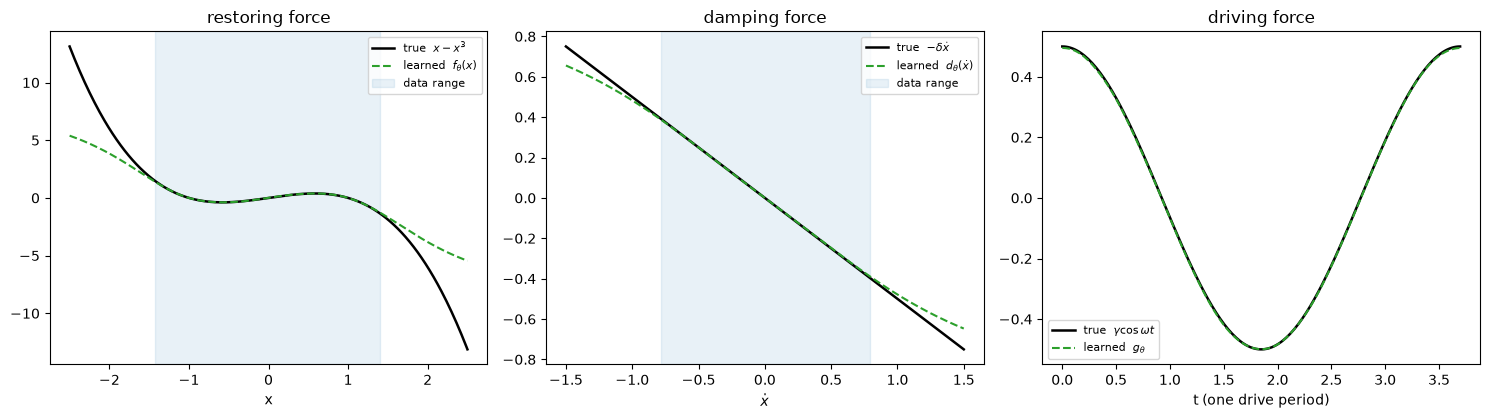

max |f error|   in data range 7.39e-02   at x = ±2.5: 7.73e+00
max |d error|   in data range 7.10e-03
max |g error|   5.12e-03


In [7]:
term_f = jax.vmap(lambda x: additive_terms(params_a,
                  jnp.array([x, 0.0]), 0.0)[0])
term_d = jax.vmap(lambda v: additive_terms(params_a,
                  jnp.array([0.0, v]), 0.0)[1])

T_DRIVE = 2 * np.pi / OMEGA
t_cycle = np.linspace(0.0, T_DRIVE, 200)
term_g = jax.vmap(lambda t: additive_terms(params_a,
                  jnp.array([0.0, 0.0]), t)[2])

g_vals = np.asarray(term_g(jnp.asarray(t_cycle)))
c_g = g_vals.mean()
c_d = float(term_d(jnp.array([0.0]))[0])
print(f'gauge constants:  mean(g) = {c_g:+.4f}   d(0) = {c_d:+.4f}'
      f'   (moved into f)')

x_plot = np.linspace(-2.5, 2.5, 400)
v_plot = np.linspace(-1.5, 1.5, 400)
f_vals = np.asarray(term_f(jnp.asarray(x_plot))) + c_g + c_d
d_vals = np.asarray(term_d(jnp.asarray(v_plot))) - c_d
g_tilde = g_vals - c_g

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
a = ax[0]
a.plot(x_plot, x_plot - x_plot**3, 'k', lw=1.8, label='true  $x - x^3$')
a.plot(x_plot, f_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $f_\theta(x)$')
a.axvspan(pts[:, 0].min(), pts[:, 0].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel('x'); a.set_title('restoring force')
a.legend(fontsize=8)

a = ax[1]
a.plot(v_plot, -DELTA * v_plot, 'k', lw=1.8,
       label=r'true  $-\delta\dot{x}$')
a.plot(v_plot, d_vals, '--', color='tab:green', lw=1.5,
       label=r'learned  $d_\theta(\dot{x})$')
a.axvspan(pts[:, 1].min(), pts[:, 1].max(), color='tab:blue', alpha=0.10,
          label='data range')
a.set_xlabel(r'$\dot{x}$'); a.set_title('damping force')
a.legend(fontsize=8)

a = ax[2]
a.plot(t_cycle, GAMMA * np.cos(OMEGA * t_cycle), 'k', lw=1.8,
       label=r'true  $\gamma\cos\omega t$')
a.plot(t_cycle, g_tilde, '--', color='tab:green', lw=1.5,
       label=r'learned  $g_\theta$')
a.set_xlabel('t (one drive period)'); a.set_title('driving force')
a.legend(fontsize=8)
plt.tight_layout(); plt.show()

in_x = (x_plot > pts[:, 0].min()) & (x_plot < pts[:, 0].max())
in_v = (v_plot > pts[:, 1].min()) & (v_plot < pts[:, 1].max())
print(f'max |f error|   in data range {np.abs(f_vals - (x_plot - x_plot**3))[in_x].max():.2e}'
      f'   at x = ±2.5: {np.abs(f_vals - (x_plot - x_plot**3))[[0, -1]].max():.2e}')
print(f'max |d error|   in data range {np.abs(d_vals + DELTA * v_plot)[in_v].max():.2e}')
print(f'max |g error|   {np.abs(g_tilde - GAMMA * np.cos(OMEGA * t_cycle)).max():.2e}')

## What this rung settles — and what it sets up

Things to read off the results above:

1. **baseline → scalar**: what hardwiring $\dot{x}_1 = x_2$ is worth on its own.
2. **scalar → additive**: what forbidding cross-terms is worth — the additive model
   cannot invent interactions like $x\dot{x}$ off-data, and each force is trained
   everywhere its own 1-D variable was visited, not just where the joint $(x, \dot{x})$
   pair was.
3. **The overlay panels**: the model hands back the *laws*, term by term, without ever
   being told them — and its far-field failure localizes to exactly one curve, the
   saturating $f_\theta$ against the growing cubic.

Next rungs, each one ingredient: sinusoidal drive $g = a\cos\omega t + b\sin\omega t$
(two parameters, read off amplitude and phase); dissipative damping
$d_\theta(\dot{x}) = -\dot{x}\,\mathrm{softplus}(h_\theta(\dot{x}))$ (energy budget
respected by construction); polynomial skeleton $f_\theta(x) = c_1 x + c_3 x^3 + \text{MLP}$
(far field cubic by construction — the fix the $f$ panel is asking for); one-well stress
test on the winner; SINDy coda.